In [ ]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio

from joblib import Parallel, delayed
from scipy.ndimage import uniform_filter, sobel
from sklearn.metrics import classification_report, confusion_matrix, jaccard_score
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from xgboost import XGBClassifier


ROOT = Path('.')
DATA_DIR = ROOT / 'data'
RANDOM_STATE = 42
MIN_CONFIDENCE = 20
CONFIDENCE_FLOOR = 0.25
WATER_WEIGHT_MULTIPLIER = 3.0
CEMENT_WEIGHT_MULTIPLIER = 2.0

BAND_MEANS = None
BAND_STDS = None

TRAIN_CAPS = {
    1: 200_000,   # Greenery
    2: 200_000,   # Sand
    3: None,      # Water -> keep all
    4: None,      # Cement -> keep all
}

VAL_TEST_CAPS = {
    1: 100_000,   # Greenery
    2: 100_000,   # Sand
    3: None,      # Water -> keep all
    4: None,      # Cement -> keep all
}

CLASS_NAMES = {
    0: 'Unknown',
    1: 'Greenery',
    2: 'Sand',
    3: 'Water',
    4: 'Cement',
}

LABEL_TO_XGB = {1: 0, 2: 1, 3: 2, 4: 3}
XGB_TO_LABEL = {v: k for k, v in LABEL_TO_XGB.items()}


In [2]:
def extract_sample_id(path):
    match = re.search(r'(\d+)', Path(path).stem)
    if not match:
        raise ValueError(f'Could not extract numeric id from {path}')
    return match.group(1)


def build_pairs_dataframe(data_dir):
    img_paths = {extract_sample_id(p): p for p in (data_dir / 'imgs').glob('*.tif')}
    mask_paths = {extract_sample_id(p): p for p in (data_dir / 'masks').glob('*.tif')}

    if set(img_paths) != set(mask_paths):
        missing_imgs = sorted(set(mask_paths) - set(img_paths))
        missing_masks = sorted(set(img_paths) - set(mask_paths))
        raise ValueError(f'Unpaired files found. missing_imgs={missing_imgs[:5]} missing_masks={missing_masks[:5]}')

    rows = []
    for sample_id in sorted(img_paths, key=int):
        rows.append(
            {
                'sample_id': sample_id,
                'img_path': str(img_paths[sample_id]),
                'mask_path': str(mask_paths[sample_id]),
            }
        )

    return pd.DataFrame(rows)


def mask_summary(mask_path):
    with rasterio.open(mask_path) as src:
        mask = src.read(1)

    values, counts = np.unique(mask, return_counts=True)
    summary = {int(v): int(c) for v, c in zip(values, counts)}
    total = int(mask.size)

    return {
        'total_pixels': total,
        'has_water': int(3 in summary),
        'has_cement': int(4 in summary),
        'has_sand': int(2 in summary),
        **{f'count_{cls}': summary.get(cls, 0) for cls in range(5)},
    }


def build_metadata(data_dir):
    pairs = build_pairs_dataframe(data_dir)
    summaries = [mask_summary(path) for path in tqdm(pairs['mask_path'], desc='Scanning masks')]
    meta = pd.concat([pairs, pd.DataFrame(summaries)], axis=1)
    return meta


def compute_band_stats(img_paths):
    band_sum = None
    band_sumsq = None
    total_pixels = 0

    for img_path in tqdm(list(img_paths), desc='Computing band stats'):
        with rasterio.open(img_path) as src:
            img = src.read()[:12].astype(np.float32)

        img = np.clip(img, 0, 10000) / 10000.0
        flat = img.reshape(img.shape[0], -1)

        if band_sum is None:
            band_sum = np.zeros(flat.shape[0], dtype=np.float64)
            band_sumsq = np.zeros(flat.shape[0], dtype=np.float64)

        band_sum += flat.sum(axis=1)
        band_sumsq += np.square(flat).sum(axis=1)
        total_pixels += flat.shape[1]

    means = band_sum / total_pixels
    stds = np.sqrt(np.maximum(band_sumsq / total_pixels - means ** 2, 1e-8))
    return means.astype(np.float32), stds.astype(np.float32)


def build_strata(df):
    strata = np.where(
        (df['has_water'] == 1) & (df['has_cement'] == 1),
        'water_and_cement',
        np.where(
            df['has_water'] == 1,
            'water_only',
            np.where(df['has_cement'] == 1, 'cement_only', 'base')
        ),
    )

    strata = pd.Series(strata, index=df.index)
    counts = strata.value_counts()
    strata = strata.where(strata.map(counts) >= 2, 'base')
    return strata


def split_metadata(meta, random_state=RANDOM_STATE):
    meta = meta.copy()
    meta['stratum'] = build_strata(meta)

    train_df, temp_df = train_test_split(
        meta,
        test_size=0.30,
        random_state=random_state,
        stratify=meta['stratum'],
    )

    temp_df = temp_df.copy()
    temp_df['stratum'] = build_strata(temp_df)
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=random_state,
        stratify=temp_df['stratum'],
    )

    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


def print_split_summary(name, df):
    print(f'[{name}] images: {len(df)}')
    for cls in range(5):
        pixels = int(df[f'count_{cls}'].sum())
        images = int((df[f'count_{cls}'] > 0).sum())
        print(f"  {CLASS_NAMES[cls]:<8} pixels={pixels:>9,} images={images:>3}")
    print('  strata:', df['stratum'].value_counts().to_dict())

def plot_class_distribution(y, title):
    classes, counts = np.unique(y, return_counts=True)
    labels = [f"{int(cls)} - {CLASS_NAMES.get(int(cls), f'Class {int(cls)}')}" for cls in classes]

    plt.figure(figsize=(8, 4))
    bars = plt.bar(
        labels,
        counts,
        color=["#4CAF50", "#D2B48C", "#1E88E5", "#9E9E9E"][: len(labels)],
    )
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Pixel count")
    plt.grid(axis="y", linestyle="--", alpha=0.3)

    for bar, count in zip(bars, counts):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            count,
            f"{int(count):,}",
            ha="center",
            va="bottom",
        )

    plt.tight_layout()
    plt.show()


meta = build_metadata(DATA_DIR)
train_meta, val_meta, test_meta = split_metadata(meta)
BAND_MEANS, BAND_STDS = compute_band_stats(train_meta['img_path'])

print_split_summary('train', train_meta)
print_split_summary('val', val_meta)
print_split_summary('test', test_meta)
print('Band means:', np.round(BAND_MEANS, 6).tolist())
print('Band stds :', np.round(BAND_STDS, 6).tolist())


Computing band stats: 100%|██████████| 147/147 [00:00<00:00, 148.45it/s]

[train] images: 147
  Unknown  pixels=    4,896 images= 32
  Greenery pixels=7,034,253 images=137
  Sand     pixels=2,034,749 images=116
  Water    pixels=  214,456 images= 25
  Cement   pixels=  345,438 images=107
  strata: {'cement_only': 86, 'base': 36, 'water_and_cement': 21, 'water_only': 4}
[val] images: 31
  Unknown  pixels=      529 images= 10
  Greenery pixels=1,417,652 images= 26
  Sand     pixels=  519,641 images= 26
  Water    pixels=   76,471 images=  6
  Cement   pixels=   17,323 images= 23
  strata: {'cement_only': 18, 'base': 7, 'water_and_cement': 5, 'water_only': 1}
[test] images: 32
  Unknown  pixels=      389 images=  9
  Greenery pixels=1,624,375 images= 30
  Sand     pixels=  373,650 images= 24
  Water    pixels=   20,362 images=  5
  Cement   pixels=   78,376 images= 23
  strata: {'cement_only': 19, 'base': 8, 'water_and_cement': 4, 'water_only': 1}
Band means: [0.05390800163149834, 0.06804099678993225, 0.10363499820232391, 0.1292009949684143, 0.1721460074186325,

In [3]:
def normalized_diff(a, b, eps=1e-6):
    return (a - b) / (a + b + eps)


def preprocess_img(img_path, mask_path):
    with rasterio.open(img_path) as src:
        img = src.read().astype(np.float32)
    with rasterio.open(mask_path) as src:
        mask = src.read(1)
        if src.count >= 2:
            confidence = src.read(2).astype(np.float32)
        else:
            confidence = np.full(mask.shape, 100.0, dtype=np.float32)

    img = np.clip(img, 0, 10000) / 10000.0
    confidence = np.clip(confidence / 100.0, CONFIDENCE_FLOOR, 1.0)
    return img, mask, confidence


def local_mean_std(img, size=5):
    mean = uniform_filter(img, size=size)
    mean_sq = uniform_filter(img * img, size=size)
    var = np.maximum(mean_sq - mean * mean, 0.0)
    std = np.sqrt(var)
    return mean, std

def local_var(img, size=5):
    mean = uniform_filter(img, size=size)
    mean_sq = uniform_filter(img * img, size=size)
    var = np.maximum(mean_sq - mean * mean, 0.0)
    return var

def edge_magnitude(img):
    gx = sobel(img, axis=0)
    gy = sobel(img, axis=1)
    return np.hypot(gx, gy)

def extract_features(img):
    b_raw = img.astype(np.float32)

    blue = b_raw[1]
    green = b_raw[2]
    red = b_raw[3]
    nir = b_raw[7]
    swir1 = b_raw[10]
    swir2 = b_raw[11]

    b = (b_raw - BAND_MEANS[:, None, None]) / BAND_STDS[:, None, None]
    bands_std = np.std(b_raw, axis=0)
    brightness = np.mean(b_raw[[1, 2, 3]], axis=0)

    ndvi = normalized_diff(nir, red)
    ndwi = normalized_diff(green, nir)
    mndwi = normalized_diff(green, swir1)
    ndbi = normalized_diff(swir1, nir)
    bsi = ((swir1 + red) - (nir + blue)) / ((swir1 + red) + (nir + blue) + 1e-6)
    awei_sh = blue + 2.5 * green - 1.5 * (nir + swir1) - 0.25 * swir2
    awei_nsh = 4.0 * (green - swir1) - (0.25 * nir + 2.75 * swir2)

    red_mean_3, red_std_3 = local_mean_std(red, size=3)
    nir_mean_3, nir_std_3 = local_mean_std(nir, size=3)
    swir1_mean_3, swir1_std_3 = local_mean_std(swir1, size=3)
    swir2_mean_3, swir2_std_3 = local_mean_std(swir2, size=3)
    ndwi_mean_3, ndwi_std_3 = local_mean_std(ndwi, size=3)
    mndwi_mean_3, mndwi_std_3 = local_mean_std(mndwi, size=3)

    red_mean_5, red_std_5 = local_mean_std(red, size=5)
    nir_mean_5, nir_std_5 = local_mean_std(nir, size=5)
    swir1_mean_5, swir1_std_5 = local_mean_std(swir1, size=5)
    swir2_mean_5, swir2_std_5 = local_mean_std(swir2, size=5)
    ndwi_mean_5, ndwi_std_5 = local_mean_std(ndwi, size=5)
    mndwi_mean_5, mndwi_std_5 = local_mean_std(mndwi, size=5)

    nir_var_5 = local_var(nir, size=5)
    swir1_var_5 = local_var(swir1, size=5)

    nir_edge = edge_magnitude(nir)
    swir1_edge = edge_magnitude(swir1)
    ndwi_edge = edge_magnitude(ndwi)
    mndwi_edge = edge_magnitude(mndwi)

    features = np.concatenate(
        [
            b,
            ndvi[np.newaxis, ...],
            ndwi[np.newaxis, ...],
            mndwi[np.newaxis, ...],
            ndbi[np.newaxis, ...],
            bsi[np.newaxis, ...],
            awei_sh[np.newaxis, ...],
            awei_nsh[np.newaxis, ...],
            brightness[np.newaxis, ...],

            bands_std[np.newaxis, ...],
            red_mean_3[np.newaxis, ...],
            red_std_3[np.newaxis, ...],
            nir_mean_3[np.newaxis, ...],
            nir_std_3[np.newaxis, ...],
            swir1_mean_3[np.newaxis, ...],
            swir1_std_3[np.newaxis, ...],
            swir2_mean_3[np.newaxis, ...],
            swir2_std_3[np.newaxis, ...],
            ndwi_mean_3[np.newaxis, ...],
            ndwi_std_3[np.newaxis, ...],
            mndwi_mean_3[np.newaxis, ...],
            mndwi_std_3[np.newaxis, ...],

            red_mean_5[np.newaxis, ...],
            red_std_5[np.newaxis, ...],
            nir_mean_5[np.newaxis, ...],
            nir_std_5[np.newaxis, ...],
            swir1_mean_5[np.newaxis, ...],
            swir1_std_5[np.newaxis, ...],
            swir2_mean_5[np.newaxis, ...],
            swir2_std_5[np.newaxis, ...],
            ndwi_mean_5[np.newaxis, ...],
            ndwi_std_5[np.newaxis, ...],
            mndwi_mean_5[np.newaxis, ...],
            mndwi_std_5[np.newaxis, ...],

            nir_var_5[np.newaxis, ...],
            swir1_var_5[np.newaxis, ...],

            nir_edge[np.newaxis, ...],
            swir1_edge[np.newaxis, ...],
            ndwi_edge[np.newaxis, ...],
            mndwi_edge[np.newaxis, ...],
        ],
        axis=0,
    )

    feature_names = [f'B{i + 1}' for i in range(b.shape[0])] + [
        'ndvi',
        'ndwi',
        'mndwi',
        'ndbi',
        'bsi',
        'awei_sh',
        'awei_nsh',
        'brightness',
        
        'bands_std',
        'red_mean_3',
        'red_std_3',
        'nir_mean_3',
        'nir_std_3',
        'swir1_mean_3',
        'swir1_std_3',
        'swir2_mean_3',
        'swir2_std_3',
        'ndwi_mean_3',
        'ndwi_std_3',
        'mndwi_mean_3',
        'mndwi_std_3',

        'red_mean_5',
        'red_std_5',
        'nir_mean_5',
        'nir_std_5',
        'swir1_mean_5',
        'swir1_std_5',
        'swir2_mean_5',
        'swir2_std_5',
        'ndwi_mean_5',
        'ndwi_std_5',
        'mndwi_mean_5',
        'mndwi_std_5',

        'nir_var_5',
        'swir1_var_5',

        'nir_edge',
        'swir1_edge',
        'ndwi_edge',
        'mndwi_edge',
    ]

    return features, feature_names


def process_pair(img_path, mask_path):
    img, mask, confidence = preprocess_img(img_path, mask_path)
    features, feature_names = extract_features(img)

    valid = (mask != 0) & (confidence * 100.0 >= MIN_CONFIDENCE) & (~np.all(img[:12] <= 1e-8, axis=0))
    X = features[:, valid].T.astype(np.float32)
    y = mask[valid].reshape(-1).astype(np.uint8)
    pixel_weight = confidence[valid].reshape(-1).astype(np.float32)

    return X, y, pixel_weight, feature_names


def build_dataset(split_df, n_jobs=-1):
    records = split_df[['img_path', 'mask_path']].to_dict('records')
    results = Parallel(n_jobs=n_jobs, backend='loky')(
        delayed(process_pair)(row['img_path'], row['mask_path'])
        for row in tqdm(records, desc='Building dataset')
    )

    X_parts = []
    y_parts = []
    weight_parts = []
    feature_names = None

    for X, y, pixel_weight, names in results:
        X_parts.append(X)
        y_parts.append(y)
        weight_parts.append(pixel_weight)
        if feature_names is None:
            feature_names = names

    X_all = np.concatenate(X_parts, axis=0)
    y_all = np.concatenate(y_parts, axis=0)
    weight_all = np.concatenate(weight_parts, axis=0)
    return X_all, y_all, weight_all, feature_names


In [4]:
def count_by_class(y):
    values, counts = np.unique(y, return_counts=True)
    return {CLASS_NAMES[int(v)]: int(c) for v, c in zip(values, counts)}


def sample_training_pixels(X, y, pixel_weight, caps=TRAIN_CAPS, random_state=RANDOM_STATE):
    rng = np.random.RandomState(random_state)
    chosen = []

    for cls in [1, 2, 3, 4]:
        cls_idx = np.where(y == cls)[0]
        cap = caps.get(cls, None)

        if cap is None:
            take = len(cls_idx)
            selected = cls_idx
        else:
            take = min(cap, len(cls_idx))
            selected = rng.choice(cls_idx, size=take, replace=False)

        chosen.append(selected)
        print(f'{CLASS_NAMES[cls]:<8} available={len(cls_idx):>9,} sampled={take:>9,}')

    chosen = np.concatenate(chosen)
    rng.shuffle(chosen)
    return X[chosen], y[chosen], pixel_weight[chosen]


def encode_labels(y):
    return np.array([LABEL_TO_XGB[int(v)] for v in y], dtype=np.uint8)


def decode_labels(y):
    return np.array([XGB_TO_LABEL[int(v)] for v in y], dtype=np.uint8)


def evaluate_split(name, model, X, y):
    y_pred = decode_labels(model.predict(X))
    print(f'===== {name} =====')
    print(classification_report(y, y_pred, digits=4, labels=[1, 2, 3, 4]))
    cm = confusion_matrix(y, y_pred, labels=[1, 2, 3, 4])
    print('Confusion Matrix:\n', cm)

    macro_iou = jaccard_score(y, y_pred, average='macro', labels=[1, 2, 3, 4])
    per_class_iou = jaccard_score(y, y_pred, average=None, labels=[1, 2, 3, 4])
    print('mIoU:', macro_iou)
    print('Per-class IoU:', {CLASS_NAMES[cls]: float(score) for cls, score in zip([1, 2, 3, 4], per_class_iou)})

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(4), [CLASS_NAMES[c] for c in [1, 2, 3, 4]], rotation=45, ha='right')
    ax.set_yticks(range(4), [CLASS_NAMES[c] for c in [1, 2, 3, 4]])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{name} Confusion Matrix')
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{cm[i, j]}', ha='center', va='center', color='black')
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

    return cm, macro_iou, per_class_iou


Building dataset: 100%|██████████| 32/32 [00:00<00:00, 37241.32it/s]


Train full: (9595649, 51) {'Greenery': 7034253, 'Sand': 2001502, 'Water': 214456, 'Cement': 345438}
Val      : (2031087, 51) {'Greenery': 1417652, 'Sand': 519641, 'Water': 76471, 'Cement': 17323}
Test     : (2096763, 51) {'Greenery': 1624375, 'Sand': 373650, 'Water': 20362, 'Cement': 78376}
Train confidence weight range: 0.33000001311302185 1.0
Greenery available=7,034,253 sampled=  200,000
Sand     available=2,001,502 sampled=  200,000
Water    available=  214,456 sampled=  214,456
Cement   available=  345,438 sampled=  345,438
Greenery available=1,417,652 sampled=  100,000
Sand     available=  519,641 sampled=  100,000
Water    available=   76,471 sampled=   76,471
Cement   available=   17,323 sampled=   17,323
Greenery available=1,624,375 sampled=  100,000
Sand     available=  373,650 sampled=  100,000
Water    available=   20,362 sampled=   20,362
Cement   available=   78,376 sampled=   78,376
Train sampled: (959894, 51) {'Greenery': 200000, 'Sand': 200000, 'Water': 214456, 'Cement

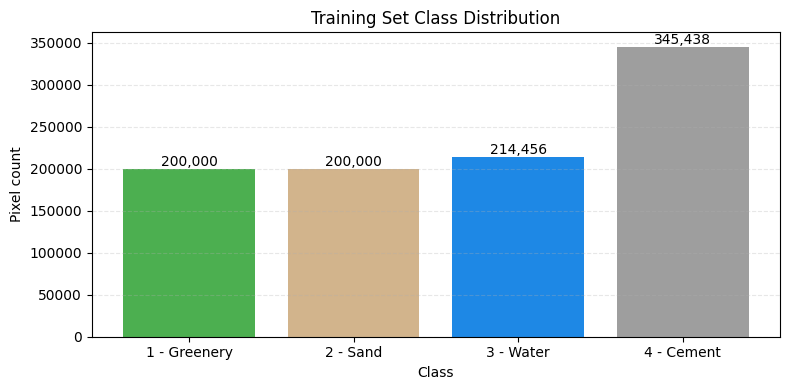

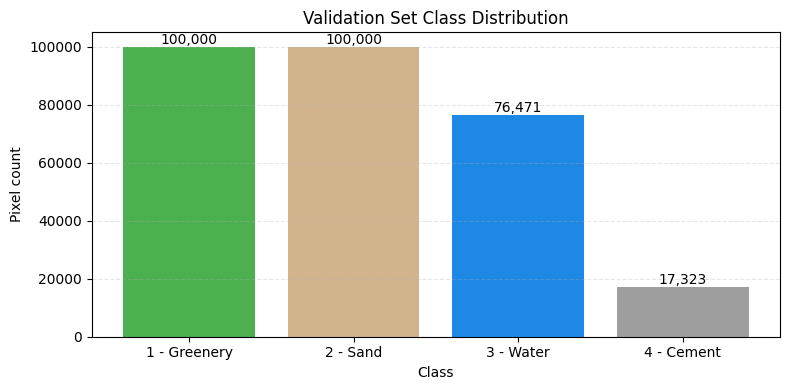

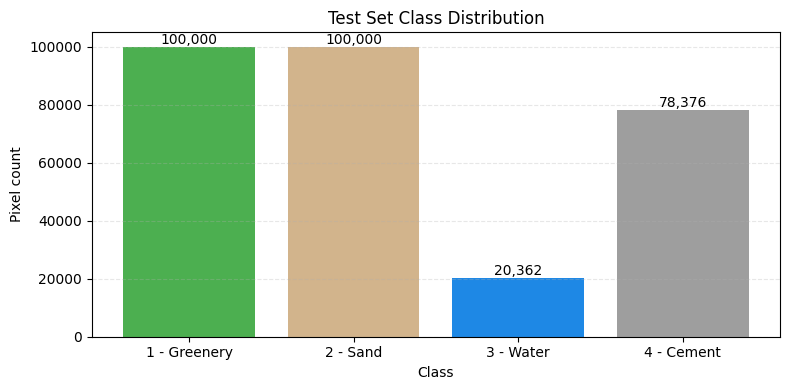

In [5]:
X_train_full, y_train_full, conf_train_full, feature_names = build_dataset(train_meta)
X_val, y_val, _, _ = build_dataset(val_meta)
X_test, y_test, _, _ = build_dataset(test_meta)

print('Train full:', X_train_full.shape, count_by_class(y_train_full))
print('Val      :', X_val.shape, count_by_class(y_val))
print('Test     :', X_test.shape, count_by_class(y_test))
print('Train confidence weight range:', float(conf_train_full.min()), float(conf_train_full.max()))

X_train, y_train, conf_train = sample_training_pixels(X_train_full, y_train_full, conf_train_full)
X_val, y_val, _ = sample_training_pixels(X_val, y_val, np.ones_like(y_val), caps=VAL_TEST_CAPS)
X_test, y_test, _ = sample_training_pixels(X_test, y_test, np.ones_like(y_test), caps=VAL_TEST_CAPS)
print('Train sampled:', X_train.shape, count_by_class(y_train))
print('Val sampled  :', X_val.shape, count_by_class(y_val))
print('Test sampled :', X_test.shape, count_by_class(y_test))
plot_class_distribution(y_train, 'Training Set Class Distribution')
plot_class_distribution(y_val, 'Validation Set Class Distribution')
plot_class_distribution(y_test, 'Test Set Class Distribution')

In [6]:
y_train_enc = encode_labels(y_train)
sample_weight = conf_train.copy()
sample_weight[y_train == 3] *= WATER_WEIGHT_MULTIPLIER
sample_weight[y_train == 4] *= CEMENT_WEIGHT_MULTIPLIER
print('Weighted classes:', {
    'Water': WATER_WEIGHT_MULTIPLIER,
    'Cement': CEMENT_WEIGHT_MULTIPLIER,
})

model = XGBClassifier(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.80,
    colsample_bytree=0.80,
    min_child_weight=3,
    reg_alpha=0.05,
    reg_lambda=1.5,
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    tree_method='hist',
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

model.fit(X_train, y_train_enc, sample_weight=sample_weight)


Weighted classes: {'Water': 3.0, 'Cement': 2.0}


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

===== Train =====
              precision    recall  f1-score   support

           1     0.8510    0.9398    0.8932    200000
           2     0.9704    0.8284    0.8938    200000
           3     0.9939    0.9999    0.9969    214456
           4     0.9589    0.9786    0.9686    345438

    accuracy                         0.9440    959894
   macro avg     0.9435    0.9367    0.9381    959894
weighted avg     0.9466    0.9440    0.9436    959894

Confusion Matrix:
 [[187962   4128    389   7521]
 [ 26826 165682    526   6966]
 [    11      0 214434     11]
 [  6083    924    391 338040]]
mIoU: 0.8869982231696316
Per-class IoU: {'Greenery': 0.8069809376609994, 'Sand': 0.8079999219710122, 'Water': 0.9938450700308673, 'Cement': 0.9391669630156472}


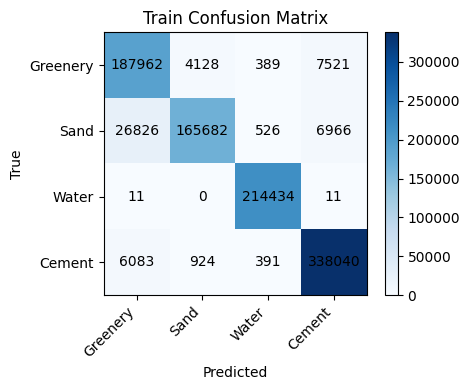

(array([[187962,   4128,    389,   7521],
        [ 26826, 165682,    526,   6966],
        [    11,      0, 214434,     11],
        [  6083,    924,    391, 338040]]),
 0.8869982231696316,
 array([0.80698094, 0.80799992, 0.99384507, 0.93916696]))

In [7]:
evaluate_split("Train", model, X_train, y_train)

===== Validation =====
              precision    recall  f1-score   support

           1     0.7995    0.8847    0.8400    100000
           2     0.9214    0.8385    0.8780    100000
           3     0.9945    0.9528    0.9732     76471
           4     0.5481    0.5971    0.5715     17323

    accuracy                         0.8698    293794
   macro avg     0.8159    0.8183    0.8157    293794
weighted avg     0.8769    0.8698    0.8718    293794

Confusion Matrix:
 [[88474  5012   131  6383]
 [13938 83851   268  1943]
 [ 2456   950 72861   204]
 [ 5788  1188     3 10344]]
mIoU: 0.7136479934491656
Per-class IoU: {'Greenery': 0.7241164819695208, 'Sand': 0.7825571628558096, 'Water': 0.9478100243258362, 'Cement': 0.4001083046454957}


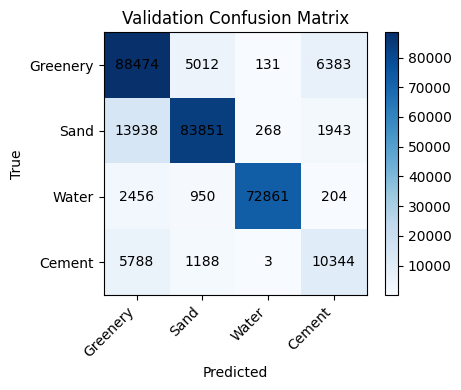

(array([[88474,  5012,   131,  6383],
        [13938, 83851,   268,  1943],
        [ 2456,   950, 72861,   204],
        [ 5788,  1188,     3, 10344]]),
 0.7136479934491656,
 array([0.72411648, 0.78255716, 0.94781002, 0.4001083 ]))

In [8]:
evaluate_split('Validation', model, X_val, y_val)

===== Test =====
              precision    recall  f1-score   support

           1     0.6787    0.8993    0.7736    100000
           2     0.8874    0.7268    0.7991    100000
           3     0.6891    0.0065    0.0129     20362
           4     0.8595    0.9229    0.8901     78376

    accuracy                         0.7869    298738
   macro avg     0.7787    0.6389    0.6189    298738
weighted avg     0.7967    0.7869    0.7609    298738

Confusion Matrix:
 [[89930  6274    36  3760]
 [19366 72679     0  7955]
 [20123     0   133   106]
 [ 3078  2944    24 72330]]
mIoU: 0.5261660029295232
Per-class IoU: {'Greenery': 0.6307911367988385, 'Sand': 0.6654489186764087, 'Water': 0.006512584467730878, 'Cement': 0.8019113717751145}


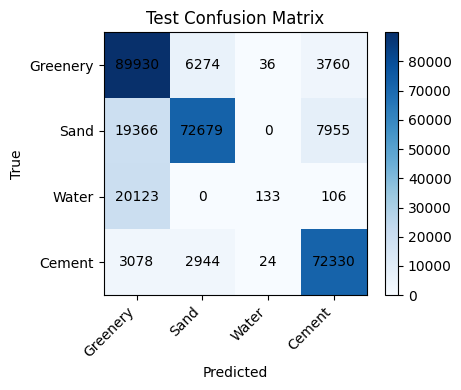

(array([[89930,  6274,    36,  3760],
        [19366, 72679,     0,  7955],
        [20123,     0,   133,   106],
        [ 3078,  2944,    24, 72330]]),
 0.5261660029295232,
 array([0.63079114, 0.66544892, 0.00651258, 0.80191137]))

In [9]:
evaluate_split('Test', model, X_test, y_test)

In [10]:
importance_df = pd.DataFrame(
    {
        'feature': feature_names,
        'importance': model.feature_importances_,
    }
).sort_values('importance', ascending=False)

display(importance_df.head(20))

,feature,importance
25,swir1_mean_3,0.304158
18,awei_nsh,0.161965
34,red_std_5,0.086553
17,awei_sh,0.078126
37,swir1_mean_5,0.071499
12,ndvi,0.042943
41,ndwi_mean_5,0.040983
29,ndwi_mean_3,0.039486
22,red_std_3,0.023533
27,swir2_mean_3,0.012506
